# 12 — Visualisasi Statistik dengan Seaborn

**Seaborn** adalah library visualisasi di atas matplotlib yang dirancang khusus untuk  **statistik**. Dengan satu-dua baris kode, kita bisa membuat grafik cantik yang langsung menampilkan distribusi, hubungan, dan ringkasan data. Di notebook ini kita memakai data nyata **kualitas anggur merah** untuk berlatih beragam grafik seaborn.

> 🎯 **Tujuan Pembelajaran**
> - Membuat `histplot` & `kdeplot` untuk melihat **distribusi**.
> - Membuat `boxplot` & `violinplot` untuk membandingkan **antar grup**.
> - Membuat **heatmap korelasi** untuk melihat hubungan antar fitur.
> - Membuat `pairplot` untuk melihat banyak hubungan sekaligus.
> - Memakai `barplot` dengan **estimator** (rata-rata) lengkap dengan interval kepercayaan.


## 📊 Tentang Dataset

Kita memakai **Red Wine Quality** dari UCI — hasil uji laboratorium 1.599 sampel anggur merah Portugal "Vinho Verde". Setiap baris berisi sifat kimia anggur dan skor kualitasnya.

- **Sumber:** [Kaggle — uciml/red-wine-quality-cortez-et-al-2009](https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009)
- **Jumlah data:** 1.599 baris × 12 kolom

| Kolom | Arti |
|-------|------|
| `fixed acidity` | Keasaman tetap (asam tartarat) |
| `volatile acidity` | Keasaman menguap (asam asetat — bila tinggi terasa seperti cuka) |
| `citric acid` | Asam sitrat (menambah kesegaran) |
| `residual sugar` | Sisa gula |
| `chlorides` | Kadar garam |
| `free sulfur dioxide` / `total sulfur dioxide` | Pengawet SO₂ |
| `density`, `pH`, `sulphates` | Sifat fisik & kimia lain |
| `alcohol` | Kadar alkohol (% volume) |
| `quality` | Skor kualitas 0–10 (penilaian penguji) |

## 1.Import Library

- **pandas / numpy** → mengolah data tabel & angka.
- **matplotlib.pyplot** → kanvas dasar grafik.
- **seaborn** → grafik statistik tingkat tinggi

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2.Import Dataset dari Kaggle

In [2]:
!pip install -q kaggle
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d uciml/red-wine-quality-cortez-et-al-2009

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009
License(s): DbCL-1.0
100% 25.6k/25.6k [00:00<00:00, 26.0MB/s]



In [3]:
!unzip red-wine-quality-cortez-et-al-2009.zip

Archive:  red-wine-quality-cortez-et-al-2009.zip
  inflating: winequality-red.csv     


## 3.Eksplorasi Awal

In [4]:
df = pd.read_csv('winequality-red.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
print("bentuk data:", df.shape)
df.info()

bentuk data: (1599, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [7]:
df.isna().sum().sum()

np.int64(0)

Interpretasi :   
- seluruh kolom berisi nilai numerikal
- kolom quality adalah target penilaian (y)
- terdapat 12 kolom dengan 1599 baris dalam dataset
- tidak terdapat missing value dalam dataset ini

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


Interpretasi :   
- Range Alc  = 8.4 s/d 14.9
- Range qlty = 3 s/d 8
- Range (total sulful dioxide) ini sangat lebar, bisa di asumsikan terdapat outlier dalam data ini

## 3.Distribusi 1 Variable : Histogram dan KdePlot

Pertama kita lihat sebaran kadar **alkohol**. `histplot` menggambar histogram, dan dengan
`kde=True` kita tambahkan kurva kepadatan (KDE) — versi mulus dari histogram.

#### Grafik 1 -  Histogram dengan KDE
untuk kadar alkohol

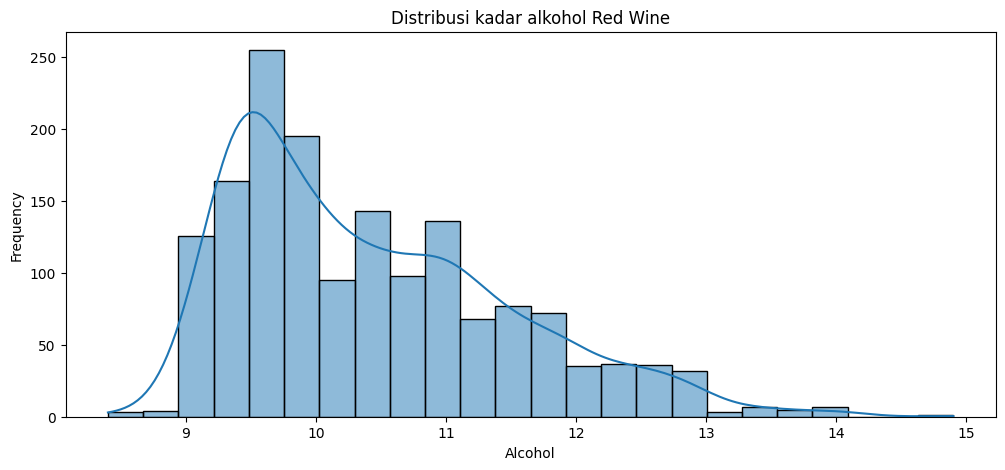

In [9]:
plt.figure(figsize=(12,5))

sns.histplot(data=df, x='alcohol', kde=True)
plt.title('Distribusi kadar alkohol Red Wine')
plt.xlabel('Alcohol %')
plt.ylabel('Frequency')
plt.show()

Interpretasi :   
- Terlihat distribusi right Skewed, miring ke kanan.
- Mayoritas anggur berkadar 9-10%
- Semakin dikit frequensi atau kuantitasnya , kadar alkoholnya semakin tinggi
- Kurva KDE ini membantu untuk melihat bentuk distribusi tanpa terganggu lebar Bin

#### Grafik 2 KDEplot Kadar alkohol dengan tingkat kualitas

Sekarang kita pisahkan KDE berdasarkan `quality` untuk melihat apakah anggur berkualitas tinggi cenderung punya alkohol lebih tinggi.

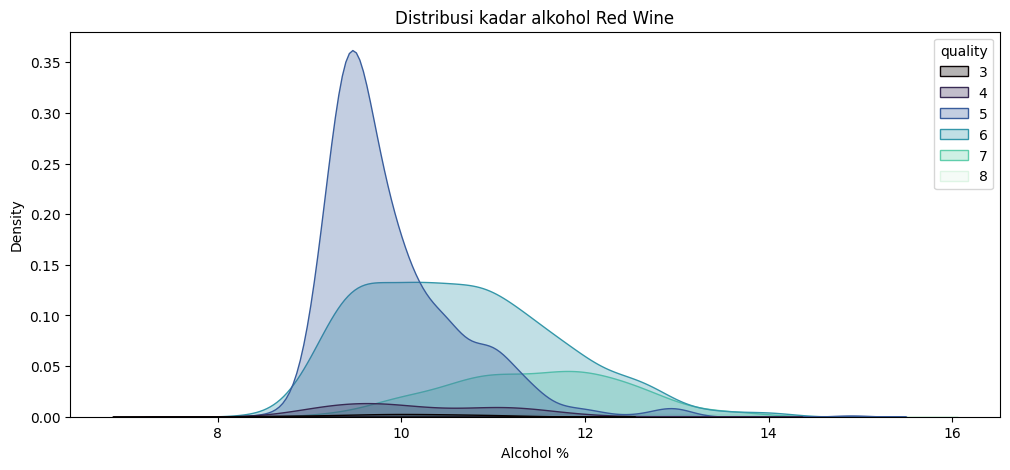

In [13]:
plt.figure(figsize=(12,5))

sns.kdeplot(data=df, x='alcohol', hue='quality', fill=True, alpha=0.3, palette="mako")
plt.title('Distribusi kadar alkohol Red Wine')
plt.xlabel('Alcohol %')
plt.ylabel('Density')
plt.show()

Interpretasi :   
- Kurva untuk kualitas tinggi (7 dan 8 ) bergeser kearah kanan
- Kurva untuk kualitas rendah (3 - 5 ) berada di sebelah kiri
- Anggur dengan kualitas terbaik, cenderung memiliki tingkat alkohol yang lebih tinggi
- gunakan heatmap untuk melihat korelasi hubungan antara tingkat alkohol dengan quality anggur ini

## 4.Membandingkan Antar Group : BoxPlot & Violinplot





`boxplot` merangkum median, kuartil, dan outlier; `violinplot` menambah informasi bentuk distribusi. Kita bandingkan kadar alkohol dan keasaman menguap antar skor kualitas.

#### Grafik 3 - BoxPlot Alkohol per Kualitas

/tmp/ipykernel_7699/1811354614.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='quality', y='alcohol', palette="mako")


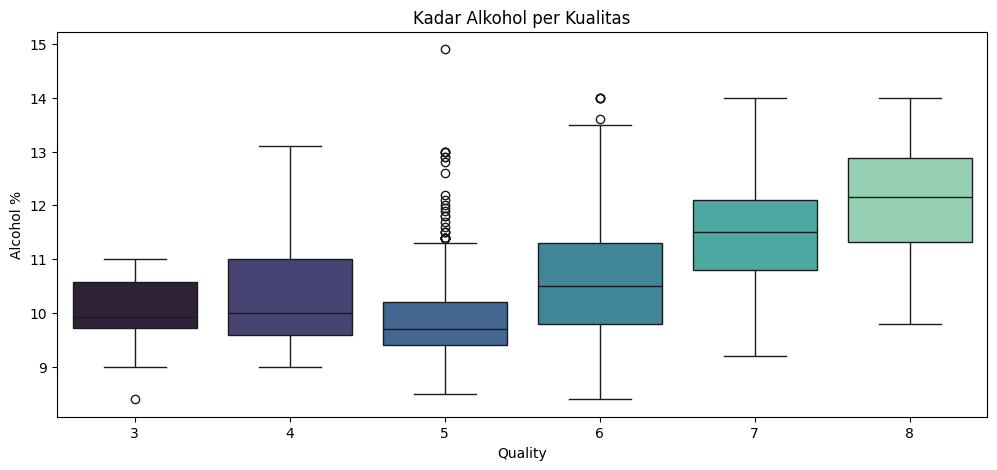

In [14]:
plt.figure(figsize=(12,5))

sns.boxplot(data=df, x='quality', y='alcohol', palette="mako")
plt.title('Kadar Alkohol per Kualitas')
plt.xlabel('Quality')
plt.ylabel('Alcohol %')
plt.show()

Interpretasi :   
- Median tingkat alkohol terlihat naik, seiring meningkatnya kualitas alkohol dalam redwine
- terlihat jelas mulai dari kualitas 5-8 terlihat kenaikan
- dari boxplot juga didapatin beberapa outlier, dan paling banyak ada di kualitas 5
- Pola ini bisa memperkuat dugaan adanya hubungan tingkat alkohol dengan kualitas anggur merah

#### Grafik 4 - Violitplot Volatile Acidity per Kualitas

/tmp/ipykernel_7699/81889653.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='quality', y='volatile acidity', palette="YlOrRd")


Text(0, 0.5, 'Volatile Acidity')

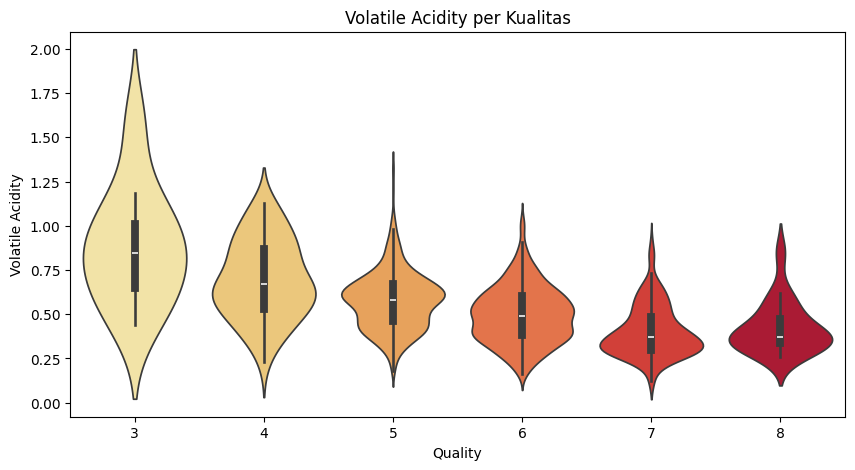

In [16]:
plt.figure(figsize=(10,5))

sns.violinplot(data=df, x='quality', y='volatile acidity', palette="YlOrRd")
plt.title('Volatile Acidity per Kualitas')
plt.xlabel('Quality')
plt.ylabel('Volatile Acidity')

Interpretasi :   
- Sebaliknya, tingkat keasaman yang tinggi mempengaruhi kualitas,
- anggur dengan tingkat keasaman tinggi berada pada kualitas terendah
- bentuk biola diatas menunjukkan dimana data terlihat paling padat
- anggur dengan kualitas tinggi terkonsentrasi dengan tingkat keasaman menguap yang rendah

## 5.Hubungan Antar fitur : Kolerasi menggunakan Heatmap

Korelasi mengukur seberapa erat 2 variable bergerak bersama, dengan nilai antara (-1 s/d 1 )  menunjukkan arah hubungan negatif atau positif.

#### Grafik 5 - Heatmap korelasi antar fitur

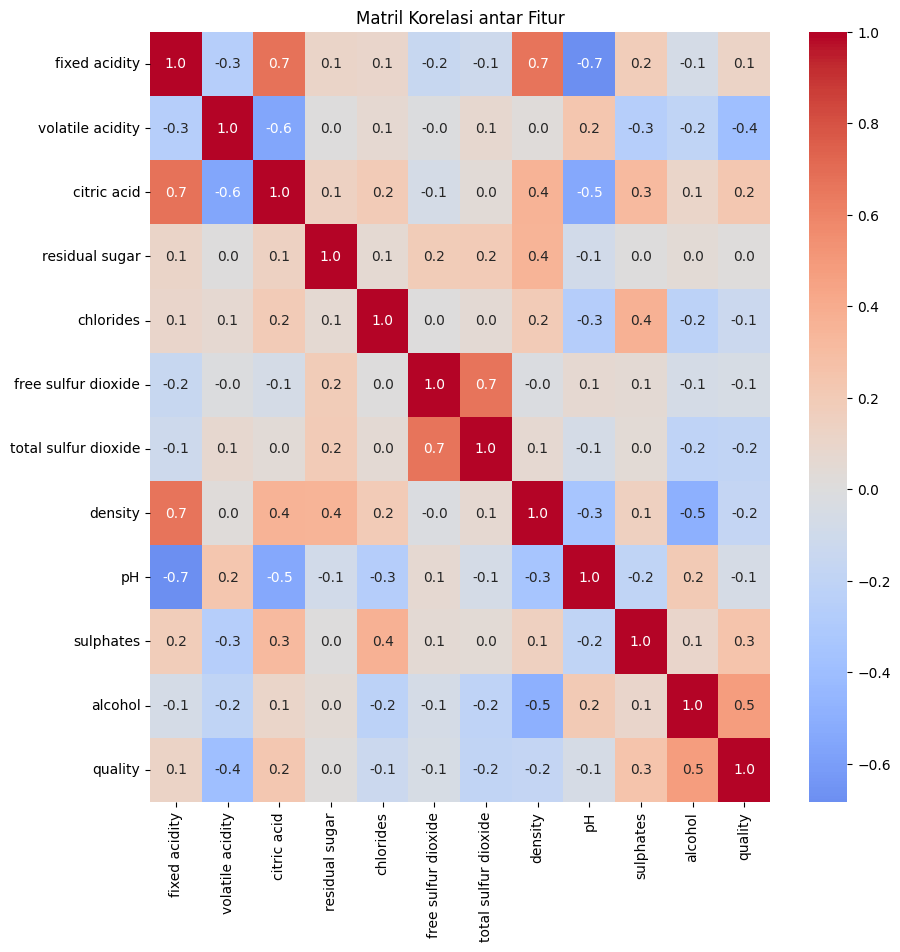

In [18]:
plt.figure(figsize=(10,10))

corr = df.corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            center=0,
            fmt=".1f")
plt.title('Matril Korelasi antar Fitur')
plt.show()

Interpretasi :   
- Fokus pada quality dengan kolom lain.
- Alkohol memiliki korelasi kuat, 0.5 dengan Quality
- Tingkat volatile acid juga mempunyai korelasi tetapi negatif -0.4
- Berdasarkan grafik sebelum heatmap ini, tingkat alkohol yang tinggi + keasaman volatile yang renah = anggur dengan kualitas terbaik
-

## 6.Banyak Hubungan Fitur : menggunakan Pairplot


Pairplot membuat matriks scatter untuk beberapa fitur sekaligus, agar mudah dalam interpretasi.

gunakan subset fitur yang paling berkaitan denga kualitas, dan buat kategori kualitas sederhana

#### Grafik 6 - Pairplot

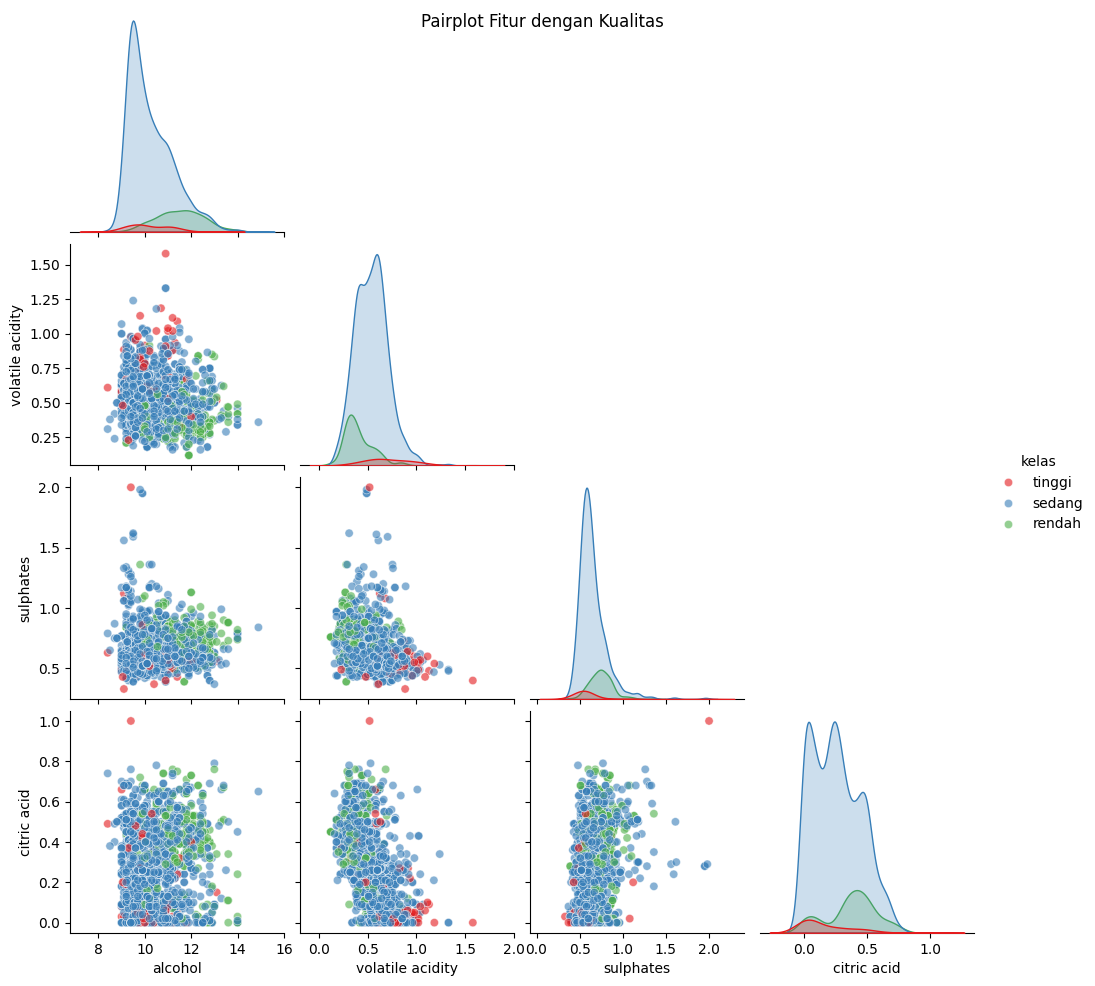

In [26]:
sbst_quality = df[["alcohol","volatile acidity","sulphates","citric acid","quality"]].copy()
sbst_quality["kelas"] = pd.cut(sbst_quality["quality"],
                               bins=[0,4,6,10],
                               labels=["tinggi","sedang","rendah"])


g = sns.pairplot(sbst_quality.drop(columns="quality"),
                 hue="kelas",
                 palette="Set1",
                 corner=True,
                 plot_kws=dict(alpha=0.6, edgecolor="w", linewidth=0.5))
g.fig.suptitle("Pairplot Fitur dengan Kualitas")
plt.show()

**Interpretasi:** Titik kelas "tinggi" (merah) cenderung berkumpul di area **alkohol & sulphates tinggi** dan **volatile acidity rendah**. Diagonal menampilkan distribusi tiap fitur per kelas. Pairplot membantu menemukan kombinasi fitur yang memisahkan kualitas.

7. BarPlot dengan Estimator


`barplot` di seaborn secara default menampilkan **rata-rata** (estimator `mean`) tiap grup, lengkap dengan garis interval kepercayaan. Kita lihat rata-rata kadar alkohol per kualitas.

#### Grafik 7 Barplot Rata rata alkohol dengan kualitas

/tmp/ipykernel_7699/2777995164.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.13/dist-packages/matplotlib/pyplot.py'>

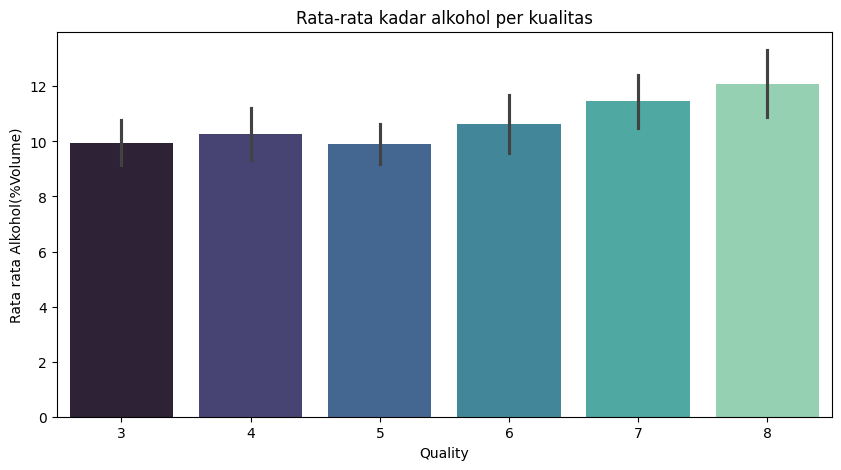

In [32]:
plt.figure(figsize=(10,5))

sns.barplot(data=df,
            x='quality',
            y='alcohol',
            estimator=np.mean,
            palette="mako",
            errorbar="sd")
plt.title('Rata-rata kadar alkohol per kualitas')
plt.xlabel('Quality')
plt.ylabel('Rata rata Alkohol(%Volume)')
plt

Interpretasi :   
- Tinggi batang = rata-rata alkohol per skor; garis hitam = sebaran (std).
- Terlihat jelas tren **menaik** dari skor 5 ke 8. Inilah kekuatan `barplot` seaborn
- menghitung agregasi statistik untuk kita secara otomatis.

## Kesimpulan & Insight

  - **Seaborn** memudahkan membuat grafik statistik: `histplot`, `kdeplot`, `boxplot`,   `violinplot`, `heatmap`, `pairplot`, dan `barplot` cukup 1–2 baris.
  - Untuk kualitas anggur merah ini, dua faktor menonjol:
    - **Alkohol** berkorelasi positif dengan kualitas (semakin tinggi, cenderung makin bagus).
    - **Volatile acidity** berkorelasi negatif (semakin tinggi, cenderung makin buruk).
  - Kombinasi grafik distribusi + perbandingan grup + korelasi memberi gambaran utuh data.


## 💡 Insight & Jebakan Data

Seaborn unggul untuk **memahami distribusi & hubungan** dengan cepat — fondasi sebelum
memutuskan fitur mana yang layak masuk model.

### ⚠️ Jebakan Data
- `pairplot` menggambar **semua pasangan fitur**; pada data dengan banyak kolom/baris ia bisa  **sangat lambat**. Batasi ke fitur kunci dulu.
- Beberapa fitur saling berkorelasi tinggi **multikolinearitas** yang membuat koefisien regresi sulit ditafsir nanti.